# Tennis Doubles Homophily — Main Analysis

Data: Grand Slam doubles matches 2018–2025 (2020: Wimbledon cancelled; AO/RG/USO included). N updated after pipeline re-run.

Sections:
1. Variable construction
2. Pressure outcomes (tiebreaks, comebacks)
3. Olympic cycle descriptive evidence
4. Baseline regressions — match win / tiebreak win / comeback win

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import statsmodels.formula.api as smf
from getpass import getuser


pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 120)
pd.set_option('display.float_format', '{:.4f}'.format)

user = getuser()
df = pd.read_excel(f'C:/Users/{user}/Documents/GitHub/tennis-homophily/data/atp/men_matches_with_ranks_cleaned.xlsx')
print(f'Loaded {df.shape[0]:,} matches | years: {sorted(df["year"].unique())}')

Loaded 1,997 matches | years: [np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]


In [2]:
# ── Missing data: key regression variables ──────────────────────────────
KEY_VARS = {
    'Country (raw)':       ['winners_p1_country',  'winners_p2_country',
                            'losers_p1_country',   'losers_p2_country'],
    'ISO3 code':           ['winners_p1_iso3',     'winners_p2_iso3',
                            'losers_p1_iso3',      'losers_p2_iso3'],
    'Same country':        ['same_country_winners', 'same_country_losers'],
    'Same language':       ['winners_same_language', 'losers_same_language'],
    'Ling. proximity':     ['winners_linguistic_proximity', 'losers_linguistic_proximity'],
    'Doubles rank':        ['winners_p1_rank_num',  'winners_p2_rank_num',
                            'losers_p1_rank_num',   'losers_p2_rank_num'],
    'GS experience':       ['winners_p1_experience_double', 'winners_p2_experience_double',
                            'losers_p1_experience_double',  'losers_p2_experience_double'],
    'Singles career high': ['winners_p1_singles_career_high_rank_num',
                            'winners_p2_singles_career_high_rank_num',
                            'losers_p1_singles_career_high_rank_num',
                            'losers_p2_singles_career_high_rank_num'],
}

n = len(df)
print(f'Dataset: {n:,} matches\n')
print(f'{"Variable group":<25} {"Cols":<6} {"NaN slots":<12} {"Matches with any NaN"}')
print('-' * 62)
for grp, cols in KEY_VARS.items():
    existing  = [c for c in cols if c in df.columns]
    nan_total = sum(df[c].isna().sum() for c in existing)
    any_nan   = df[existing].isna().any(axis=1).sum()
    print(f'{grp:<25} {len(existing):<6} {nan_total:<12} {any_nan:,}  ({100*any_nan/n:.1f}%)')


Dataset: 1,997 matches

Variable group            Cols   NaN slots    Matches with any NaN
--------------------------------------------------------------
Country (raw)             4      1            1  (0.1%)
ISO3 code                 4      1            1  (0.1%)
Same country              2      1            1  (0.1%)
Same language             2      1            1  (0.1%)
Ling. proximity           2      1            1  (0.1%)
Doubles rank              4      14           14  (0.7%)
GS experience             4      1021         687  (34.4%)
Singles career high       4      171          168  (8.4%)


## 1. Variable Construction

In [3]:
# ── Tiebreak flags ────────────────────────────────────────
# Drop likely retirements/walkovers: matches where set scores are missing
# or incomplete, indicating the match did not finish normally.
def regular_set_complete(w, l):
    valid = w.notna() & l.notna()
    hi = pd.concat([w, l], axis=1).max(axis=1)
    lo = pd.concat([w, l], axis=1).min(axis=1)
    return valid & (
        ((hi == 6) & (lo <= 4)) |
        ((hi == 7) & lo.isin([5, 6])) |
        ((hi >= 8) & ((hi - lo) == 2))
    )

def match_tiebreak_complete(w, l):
    valid = w.notna() & l.notna()
    hi = pd.concat([w, l], axis=1).max(axis=1)
    lo = pd.concat([w, l], axis=1).min(axis=1)
    return valid & (hi >= 10) & ((hi - lo) >= 2)

s1_complete = regular_set_complete(df['winners_set1'], df['losers_set1'])
s2_complete = regular_set_complete(df['winners_set2'], df['losers_set2'])
split_sets = (
    ((df['winners_set1'] > df['losers_set1']) & (df['winners_set2'] < df['losers_set2'])) |
    ((df['winners_set1'] < df['losers_set1']) & (df['winners_set2'] > df['losers_set2']))
)
s3_complete = (
    regular_set_complete(df['winners_set3'], df['losers_set3']) |
    match_tiebreak_complete(df['winners_set3'], df['losers_set3'])
)
retired_or_incomplete = ~s1_complete | ~s2_complete | (split_sets & ~s3_complete)
print(f'Dropping likely retirements/walkovers: {retired_or_incomplete.sum():,} matches')

# ── Detail of dropped matches ───────────────────────────────────────
def _classify_drop(row):
    w1, l1 = row.get('winners_set1'), row.get('losers_set1')
    w2, l2 = row.get('winners_set2'), row.get('losers_set2')
    if pd.isna(w1) and pd.isna(l1):
        return 'WALKOVER'
    if pd.notna(w1) and pd.notna(l1) and pd.notna(w2) and pd.notna(l2):
        return 'RETIREMENT-S2+'
    return 'RETIREMENT-S1'

_dropped = df[retired_or_incomplete].copy()
_dropped['drop_reason'] = _dropped.apply(_classify_drop, axis=1)
print(_dropped['drop_reason'].value_counts().to_string())
_show = ['year', 'tournament', 'stage', 'drop_reason',
         'winners_p1_surname', 'winners_p2_surname',
         'losers_p1_surname',  'losers_p2_surname',
         'winners_set1', 'losers_set1',
         'winners_set2', 'losers_set2',
         'winners_set3', 'losers_set3']
_show = [c for c in _show if c in _dropped.columns]
print()
print(_dropped.sort_values('drop_reason')[_show].to_string(index=False))

df = df.loc[~retired_or_incomplete].copy()

# Regular 7-point tiebreak: set reaches 7-6
df['tb_s1'] = ((df['winners_set1']==7)&(df['losers_set1']==6)) | ((df['winners_set1']==6)&(df['losers_set1']==7))
df['tb_s2'] = ((df['winners_set2']==7)&(df['losers_set2']==6)) | ((df['winners_set2']==6)&(df['losers_set2']==7))
df['regular_tb']    = df['tb_s1'] | df['tb_s2']
df['tb_s3_regular'] = (((df['winners_set3']==7)&(df['losers_set3']==6)) | ((df['winners_set3']==6)&(df['losers_set3']==7))).fillna(False)

# Match tiebreak / super-tiebreak (10-point, set3 >= 10)
df['match_tb'] = match_tiebreak_complete(df['winners_set3'], df['losers_set3'])
df['any_tb']   = df['regular_tb'] | df['match_tb'] | df['tb_s3_regular']

# Who won each tiebreak (winner-team perspective)
df['w_won_tb_s1'] = df['tb_s1'] & (df['winners_set1'] == 7)
df['w_won_tb_s2'] = df['tb_s2'] & (df['winners_set2'] == 7)

# ── Match structure ───────────────────────────────────────────
df['three_sets']     = df['winners_set3'].notna()
df['winner_lost_s1'] = df['winners_set1'] < df['losers_set1']
df['comeback']       = df['winner_lost_s1'] & df['three_sets']

# ── Olympic period flags ──────────────────────────────────────
def get_period(row):
    y = row['year']
    t = row['tournament']
    if y in [2018, 2019]:
        return 'Pre-Tokyo'
    elif y == 2020:
        return 'Tokyo Prep' if t != 'Wimbledon' else None
    elif y == 2021:
        if t in ['Australian Open', 'Roland Garros', 'Wimbledon']:
            return 'Tokyo Prep'
        elif t == 'US Open':
            return 'Post-Tokyo'
    elif y == 2022:
        return 'Pre-Paris'
    elif y == 2023:
        return 'Paris Prep'
    elif y == 2024:
        if t in ['Australian Open', 'Roland Garros', 'Wimbledon']:
            return 'Paris Prep'
        elif t == 'US Open':
            return 'Post-Paris'
    elif y == 2025:
        return 'Post-Paris'
    return None

df['cycle'] = df.apply(get_period, axis=1)
df['pre_olympic']    = df['cycle'].isin(['Pre-Paris', 'Paris Prep']).astype(int)
df['olympic_period'] = df['cycle'].isin(['Pre-Paris', 'Paris Prep', 'Post-Paris']).astype(int)
df['olympics_tourn'] = (df['tournament'] == 'Olympics').astype(int)

# ── Match-level homophily differences and averages ───────────────────
df['same_country_diff']  = df['same_country_winners'].astype(float)  - df['same_country_losers'].astype(float)
df['same_language_diff'] = df['winners_same_language'].astype(float) - df['losers_same_language'].astype(float)
df['ling_prox_diff']     = df['winners_linguistic_proximity'].astype(float) - df['losers_linguistic_proximity'].astype(float)

df['same_country_avg']  = (df['same_country_winners'] + df['same_country_losers']) / 2
df['same_language_avg'] = (df['winners_same_language'] + df['losers_same_language']) / 2
df['ling_prox_avg']     = (df['winners_linguistic_proximity'] + df['losers_linguistic_proximity']) / 2
print('Variable construction complete.')


Dropping likely retirements/walkovers: 48 matches
drop_reason
WALKOVER          20
RETIREMENT-S2+    18
RETIREMENT-S1     10

 year      tournament       stage    drop_reason winners_p1_surname winners_p2_surname losers_p1_surname losers_p2_surname  winners_set1  losers_set1  winners_set2  losers_set2  winners_set3  losers_set3
 2018 Australian Open Round of 16  RETIREMENT-S1              groth             hewitt           andújar           viñolas        3.0000       3.0000           NaN          NaN           NaN          NaN
 2019   Roland Garros Round of 64  RETIREMENT-S1                ram          salisbury           dzumhur        krajinovic        4.0000       5.0000           NaN          NaN           NaN          NaN
 2019   Roland Garros Round of 64  RETIREMENT-S1           berankis           nishioka          mcdonald            opelka        3.0000       0.0000           NaN          NaN           NaN          NaN
 2020   Roland Garros Round of 64  RETIREMENT-S1          

Variable construction complete.


## 2. Pressure Outcomes - Counts and Inspection

In [4]:
print(f'=== Table 1. Pressure Outcome Counts (all matches, N={len(df):,}) ===')
rows = [
    ('Set-1 tiebreak (7-pt)',                          df['tb_s1']),
    ('Set-2 tiebreak (7-pt)',                          df['tb_s2']),
    ('Set-3 regular tiebreak (7-pt)',                  df['tb_s3_regular']),
    ('Match tiebreak / super-tb (10-pt, set3 â‰¥ 8)',   df['match_tb']),
    ('Any regular tiebreak (sets 1 or 2)',             df['regular_tb']),
    ('Any tiebreak (all types)',                       df['any_tb']),
    ('Match went to 3 sets',                           df['three_sets']),
    ('Comeback wins (winner lost set 1)',               df['comeback']),
]
for lbl, s in rows:
    print(f'  {lbl:<50s}  N={int(s.sum()):4d}  ({100*s.mean():.1f}%)')

print()
print('Regular tiebreaks by tournament:')
print(df.groupby('tournament')['regular_tb'].agg(['sum','mean']).rename(columns={'sum':'N','mean':'Rate'}).round(3).to_string())

print()
print('Match tiebreaks (super-tb) by tournament/year:')
print(df[df['match_tb']].groupby(['tournament','year']).size().to_frame('N').to_string())

print()
print('Comeback wins by tournament:')
print(df.groupby('tournament')['comeback'].agg(['sum','mean']).rename(columns={'sum':'N','mean':'Rate'}).round(3).to_string())

=== Table 1. Pressure Outcome Counts (all matches, N=1,949) ===
  Set-1 tiebreak (7-pt)                               N= 476  (24.4%)
  Set-2 tiebreak (7-pt)                               N= 496  (25.4%)
  Set-3 regular tiebreak (7-pt)                       N= 211  (10.8%)
  Match tiebreak / super-tb (10-pt, set3 â‰¥ 8)       N=  24  (1.2%)
  Any regular tiebreak (sets 1 or 2)                  N= 858  (44.0%)
  Any tiebreak (all types)                            N= 958  (49.2%)
  Match went to 3 sets                                N= 852  (43.7%)
  Comeback wins (winner lost set 1)                   N= 384  (19.7%)

Regular tiebreaks by tournament:
                   N   Rate
tournament                 
Australian Open  223 0.4530
Olympics          28 0.4440
Roland Garros    163 0.3310
US Open          219 0.4720
Wimbledon        225 0.5140

Match tiebreaks (super-tb) by tournament/year:
                  N
tournament year    
Olympics   2021   9
           2024  11
Wimbledon  2018   1

### 2.1 Tiebreak types treated together vs separately

Regular tiebreaks (7-point, in sets 1-2) and match tiebreaks (10-point super-tiebreak, set 3) measure the same underlying construct - pressure in a closely contested set - but with different point thresholds. For regression purposes we treat them together as `any_tb`. Match tiebreaks are few (N=30) and concentrated in the Olympics and Wimbledon.

## 3. Olympic Cycle Descriptive Evidence


In [5]:
gs = df[df['olympics_tourn'] == 0].copy()   # Grand Slams only

hcols = ['same_country_avg', 'same_language_avg', 'ling_prox_avg']

def assign_tokyo_cycle(row):
    y = row['year']
    t = row['tournament']
    if y in [2018, 2019]:
        return 'Pre-Tokyo'
    if y == 2020:
        return 'Tokyo Prep' if t != 'Wimbledon' else None
    if y == 2021:
        if t in ['Australian Open', 'Roland Garros', 'Wimbledon']:
            return 'Tokyo Prep'
        if t == 'US Open':
            return 'Post-Tokyo'
    if y == 2022:
        return 'Post-Tokyo'
    return None


def assign_paris_cycle(row):
    y = row['year']
    t = row['tournament']

    if y == 2022:
        return 'Pre-Paris'

    if y == 2023:
        if t in ['Australian Open', 'Roland Garros', 'Wimbledon', 'US Open']:
            return 'Paris Prep'

    if y == 2024:
        if t in ['Australian Open', 'Roland Garros', 'Wimbledon']:
            return 'Paris Prep'
        if t == 'US Open':
            return 'Post-Paris'

    if y == 2025:
        return 'Post-Paris'

    return None

gs['cycle_tokyo'] = gs.apply(assign_tokyo_cycle, axis=1)
gs['cycle_paris'] = gs.apply(assign_paris_cycle, axis=1)

cycle_order_tokyo = ['Pre-Tokyo', 'Tokyo Prep', 'Post-Tokyo']
cycle_order_paris = ['Pre-Paris', 'Paris Prep', 'Post-Paris']

panel_tokyo = pd.DataFrame({
    'Period': cycle_order_tokyo,
    'Calendar window': ['Jan 2018 - Dec 2019', 'Jan 2020 - Jul 2021', 'Aug 2021 - Dec 2022'],
    'GS included': ['AO18-USO19', 'AO20-Wim21 (ex Wim20)', 'USO21-USO22'],
}).set_index('Period')

panel_paris = pd.DataFrame({
    'Period': cycle_order_paris,
    'Calendar window': ['Jan 2022 - Dec 2022', 'Jan 2023 - Jul 2024', 'Aug 2024 - Dec 2025'],
    'GS included': ['AO22-USO22', 'AO23-Wim24', 'USO24-USO25'],
}).set_index('Period')

by_tokyo = gs[gs['cycle_tokyo'].notna()].groupby('cycle_tokyo')[hcols].mean().reindex(cycle_order_tokyo) * 100
by_tokyo.columns = ['Same Nationality', 'Same Language', 'Ling. Proximity']
by_tokyo['N teams'] = gs[gs['cycle_tokyo'].notna()].groupby('cycle_tokyo').size().reindex(cycle_order_tokyo) * 2

by_paris = gs[gs['cycle_paris'].notna()].groupby('cycle_paris')[hcols].mean().reindex(cycle_order_paris) * 100
by_paris.columns = ['Same Nationality', 'Same Language', 'Ling. Proximity']
by_paris['N teams'] = gs[gs['cycle_paris'].notna()].groupby('cycle_paris').size().reindex(cycle_order_paris) * 2

panel_tokyo = panel_tokyo.join(by_tokyo)
panel_paris = panel_paris.join(by_paris)

print('=== Table 2A. Tokyo 2021 cycle - Same nat/lang/langprox by period ===')
print(panel_tokyo.round({'Same Nationality':1,'Same Language':1,'Ling. Proximity':1}).to_string())

print()
print('=== Table 2B. Paris 2024 cycle - Same nat/lang/langprox by period ===')
print(panel_paris.round({'Same Nationality':1,'Same Language':1,'Ling. Proximity':1}).to_string())

print()
print('Overall same vs. diff homophily rates (Grand Slams, all teams):')
for avg_col, lbl in [
    ('same_country_avg',  'Same nationality'),
    ('same_language_avg', 'Same language'),
    ('ling_prox_avg',     'Ling. proximity'),
]:
    same_pct = 100 * gs[avg_col].mean()
    print(f'  {lbl:<25s}  Same={same_pct:.1f}%  Diff={(100-same_pct):.1f}%')

=== Table 2A. Tokyo 2021 cycle - Same nat/lang/langprox by period ===
                Calendar window            GS included  Same Nationality  Same Language  Ling. Proximity  N teams
Period                                                                                                           
Pre-Tokyo   Jan 2018 - Dec 2019             AO18-USO19           40.1000        54.8000          55.7000     1006
Tokyo Prep  Jan 2020 - Jul 2021  AO20-Wim21 (ex Wim20)           40.4000        55.0000          55.2000      676
Post-Tokyo  Aug 2021 - Dec 2022            USO21-USO22           39.2000        55.0000          55.8000      604

=== Table 2B. Paris 2024 cycle - Same nat/lang/langprox by period ===
                Calendar window  GS included  Same Nationality  Same Language  Ling. Proximity  N teams
Period                                                                                                 
Pre-Paris   Jan 2022 - Dec 2022   AO22-USO22           39.5000        54.3000    

In [6]:
# Same vs. diff homophily by year and tournament
avg_cols = ['same_country_avg', 'same_language_avg', 'ling_prox_avg']
by_year_tourn = gs.groupby(['year', 'tournament'])[avg_cols].mean() * 100
by_year_tourn.columns = ['Same Nationality (%)', 'Same Language (%)', 'Ling. Proximity (%)']
by_year_tourn['Diff Nationality (%)'] = 100 - by_year_tourn['Same Nationality (%)']
by_year_tourn['Diff Language (%)'] = 100 - by_year_tourn['Same Language (%)']
by_year_tourn['Diff Ling. Proximity (%)'] = 100 - by_year_tourn['Ling. Proximity (%)']
by_year_tourn = by_year_tourn[['Same Nationality (%)', 'Diff Nationality (%)',
                                'Same Language (%)', 'Diff Language (%)',
                                'Ling. Proximity (%)', 'Diff Ling. Proximity (%)']]
print('=== Table 2C. Same vs. Diff homophily by year and tournament (Grand Slams only) ===')
print(by_year_tourn.round(1).to_string())

=== Table 2C. Same vs. Diff homophily by year and tournament (Grand Slams only) ===
                      Same Nationality (%)  Diff Nationality (%)  Same Language (%)  Diff Language (%)  Ling. Proximity (%)  Diff Ling. Proximity (%)
year tournament                                                                                                                                      
2018 Australian Open               38.3000               61.7000            53.3000            46.7000              55.0000                   45.0000
     Roland Garros                 40.5000               59.5000            54.0000            46.0000              57.1000                   42.9000
     US Open                       37.3000               62.7000            51.6000            48.4000              51.6000                   48.4000
     Wimbledon                     30.1000               69.9000            52.7000            47.3000              52.7000                   47.3000
2019 Australian 

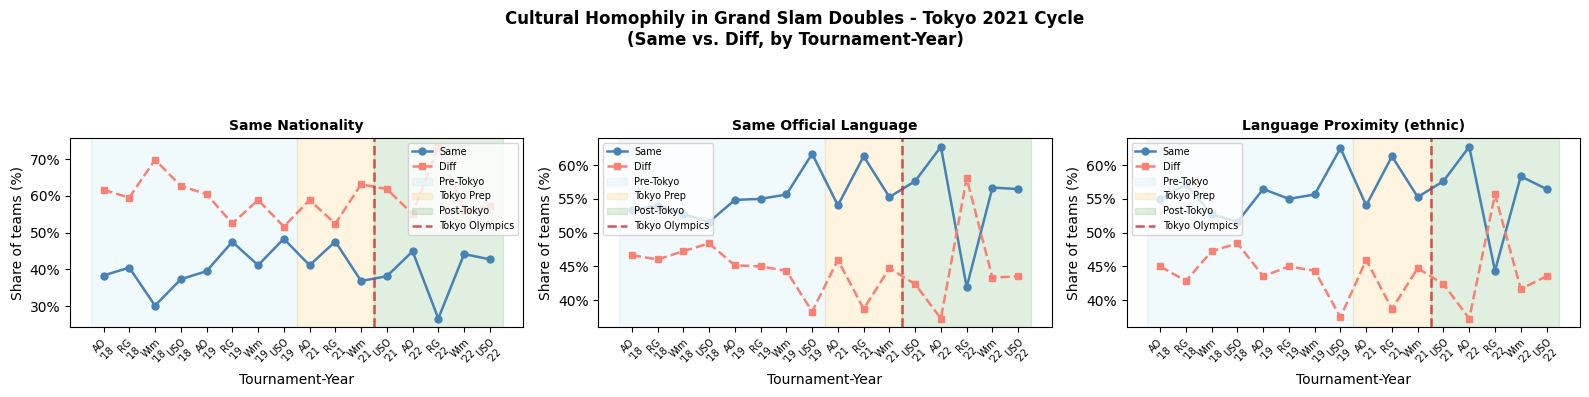

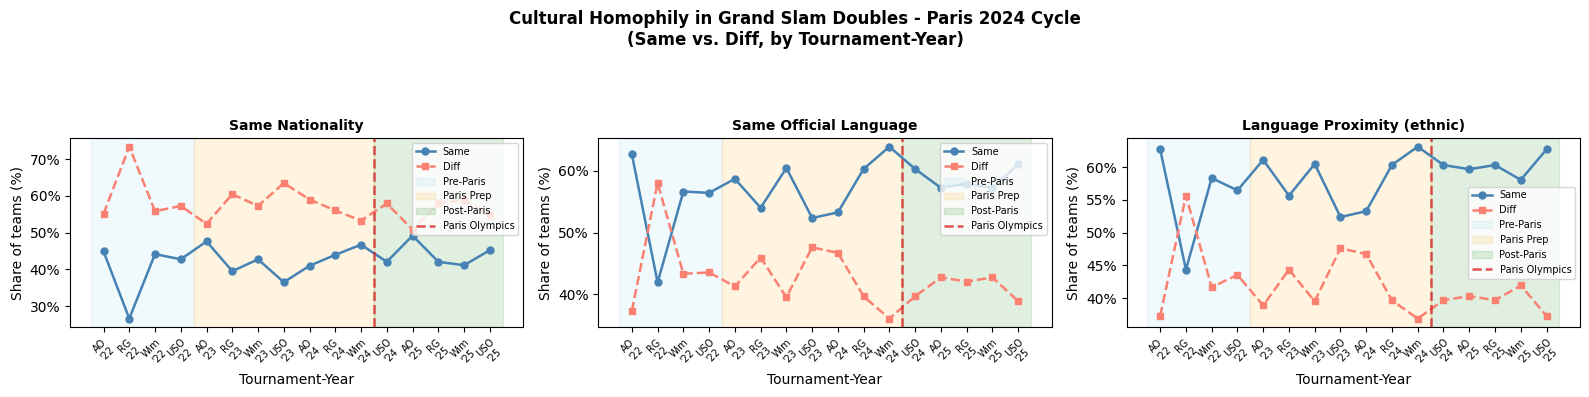

In [7]:
TOURN_ORDER = {'Australian Open': 0, 'Roland Garros': 1, 'Wimbledon': 2, 'US Open': 3}
TOURN_ABBR  = {'Australian Open': 'AO', 'Roland Garros': 'RG', 'Wimbledon': 'Wim', 'US Open': 'USO'}

avg_cols = ['same_country_avg', 'same_language_avg', 'ling_prox_avg']
titles   = ['Same Nationality', 'Same Official Language', 'Language Proximity (ethnic)']

# Chronologically-ordered tournament-year means
ty = gs.groupby(['year', 'tournament'])[avg_cols].mean().mul(100).reset_index()
ty['t_order'] = ty['tournament'].map(TOURN_ORDER)
ty = ty.sort_values(['year', 't_order']).reset_index(drop=True)
ty['label'] = ty.apply(lambda r: f"{TOURN_ABBR[r['tournament']]}\n'{str(r['year'])[2:]}", axis=1)

# ── Tokyo cycle ───────────────────────────────────────────────────────────
ty_t = ty[ty['year'].isin([2018, 2019, 2021, 2022])].reset_index(drop=True)
ty_t['x'] = ty_t.index

pre_t  = ty_t['year'].isin([2018, 2019])
prep_t = (ty_t['year'] == 2021) & ty_t['tournament'].isin(['Australian Open', 'Roland Garros', 'Wimbledon'])
post_t = ((ty_t['year'] == 2021) & (ty_t['tournament'] == 'US Open')) | (ty_t['year'] == 2022)

fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=False)
for ax, ac, ttl in zip(axes, avg_cols, titles):
    ax.plot(ty_t['x'], ty_t[ac],       marker='o', color='steelblue', lw=1.8, ms=5, label='Same')
    ax.plot(ty_t['x'], 100-ty_t[ac],   marker='s', color='salmon',    lw=1.8, ms=5, ls='--', label='Diff')
    for mask, color, lbl in [(pre_t, 'skyblue', 'Pre-Tokyo'), (prep_t, 'orange', 'Tokyo Prep'), (post_t, 'green', 'Post-Tokyo')]:
        xs = ty_t.loc[mask, 'x']
        if not xs.empty:
            ax.axvspan(xs.min() - 0.5, xs.max() + 0.5, alpha=0.12, color=color, label=lbl)
    x_wim = ty_t.loc[(ty_t['year'] == 2021) & (ty_t['tournament'] == 'Wimbledon'), 'x']
    x_uso = ty_t.loc[(ty_t['year'] == 2021) & (ty_t['tournament'] == 'US Open'),   'x']
    if not x_wim.empty and not x_uso.empty:
        ax.axvline((x_wim.values[0] + x_uso.values[0]) / 2,
                   color='#d62728', ls='--', lw=1.8, alpha=0.8, label='Tokyo Olympics')
    ax.set_title(ttl, fontsize=10, fontweight='bold')
    ax.set_xlabel('Tournament-Year'); ax.set_ylabel('Share of teams (%)')
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
    ax.set_xticks(ty_t['x']); ax.set_xticklabels(ty_t['label'], fontsize=7)
    ax.tick_params(axis='x', rotation=45); ax.legend(fontsize=7)

fig.suptitle('Cultural Homophily in Grand Slam Doubles - Tokyo 2021 Cycle\n(Same vs. Diff, by Tournament-Year)',
             fontsize=12, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.88])
plt.savefig('../../ppt/homophily_tokyo_cycle.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Paris cycle ───────────────────────────────────────────────────────────
ty_p = ty[ty['year'].isin([2022, 2023, 2024, 2025])].reset_index(drop=True)
ty_p['x'] = ty_p.index

pre_p  = ty_p['year'] == 2022
prep_p = (ty_p['year'] == 2023) | ((ty_p['year'] == 2024) & ty_p['tournament'].isin(['Australian Open', 'Roland Garros', 'Wimbledon']))
post_p = ((ty_p['year'] == 2024) & (ty_p['tournament'] == 'US Open')) | (ty_p['year'] == 2025)

fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=False)
for ax, ac, ttl in zip(axes, avg_cols, titles):
    ax.plot(ty_p['x'], ty_p[ac],       marker='o', color='steelblue', lw=1.8, ms=5, label='Same')
    ax.plot(ty_p['x'], 100-ty_p[ac],   marker='s', color='salmon',    lw=1.8, ms=5, ls='--', label='Diff')
    for mask, color, lbl in [(pre_p, 'skyblue', 'Pre-Paris'), (prep_p, 'orange', 'Paris Prep'), (post_p, 'green', 'Post-Paris')]:
        xs = ty_p.loc[mask, 'x']
        if not xs.empty:
            ax.axvspan(xs.min() - 0.5, xs.max() + 0.5, alpha=0.12, color=color, label=lbl)
    x_wim = ty_p.loc[(ty_p['year'] == 2024) & (ty_p['tournament'] == 'Wimbledon'), 'x']
    x_uso = ty_p.loc[(ty_p['year'] == 2024) & (ty_p['tournament'] == 'US Open'),   'x']
    if not x_wim.empty and not x_uso.empty:
        ax.axvline((x_wim.values[0] + x_uso.values[0]) / 2,
                   color='#d62728', ls='--', lw=1.8, alpha=0.8, label='Paris Olympics')
    ax.set_title(ttl, fontsize=10, fontweight='bold')
    ax.set_xlabel('Tournament-Year'); ax.set_ylabel('Share of teams (%)')
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
    ax.set_xticks(ty_p['x']); ax.set_xticklabels(ty_p['label'], fontsize=7)
    ax.tick_params(axis='x', rotation=45); ax.legend(fontsize=7)

fig.suptitle('Cultural Homophily in Grand Slam Doubles - Paris 2024 Cycle\n(Same vs. Diff, by Tournament-Year)',
             fontsize=12, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.88])
plt.savefig('../../ppt/homophily_paris_cycle.png', dpi=150, bbox_inches='tight')
plt.show()

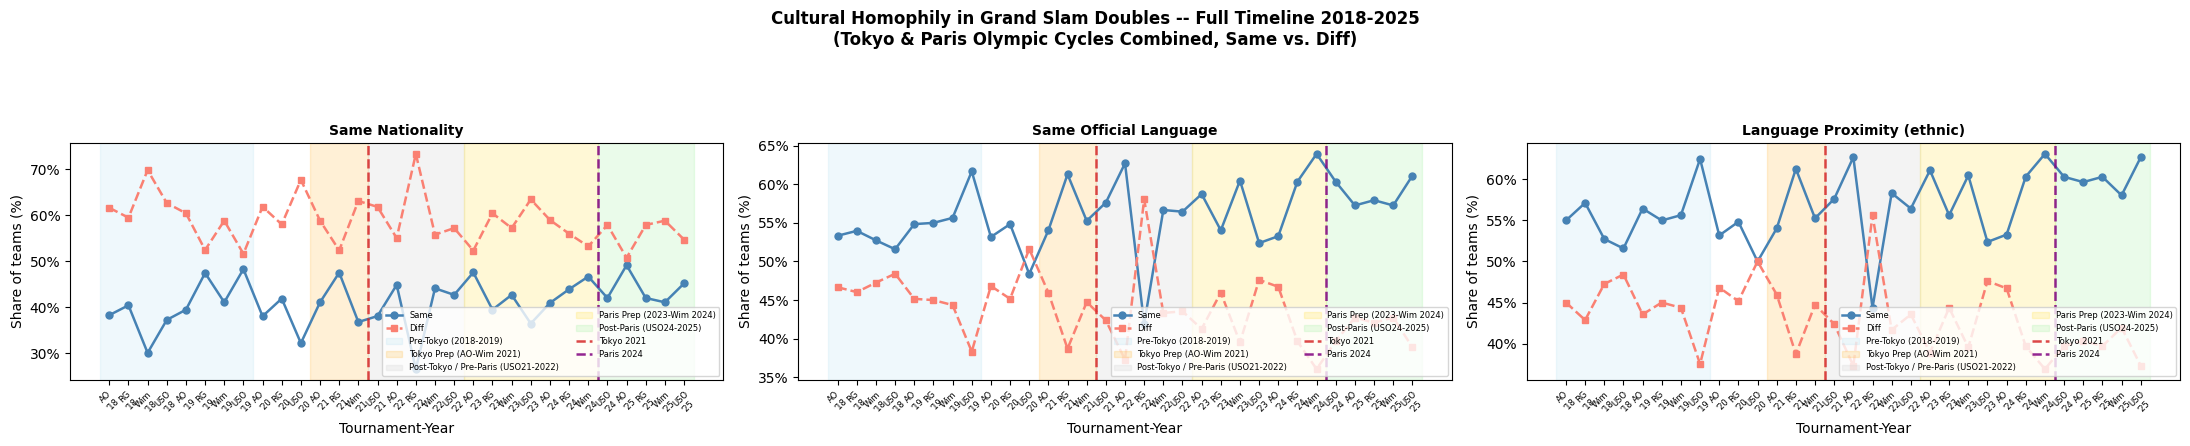

In [8]:
# Combined Tokyo + Paris cycle graph (full timeline 2018-2025)
# Single figure spanning all Grand Slams in the dataset (Olympics excluded).
# Two vertical lines mark the Olympic tournaments; shaded bands show each period.

ty_full = ty.copy()
ty_full['x'] = ty_full.index   # ty already sorted chronologically

mask_pre_tokyo  = ty_full['year'].isin([2018, 2019])
mask_tokyo_prep = (ty_full['year'] == 2021) & ty_full['tournament'].isin(['Australian Open', 'Roland Garros', 'Wimbledon'])
mask_interlude  = ((ty_full['year'] == 2021) & (ty_full['tournament'] == 'US Open')) | (ty_full['year'] == 2022)
mask_paris_prep = (ty_full['year'] == 2023) | ((ty_full['year'] == 2024) & ty_full['tournament'].isin(['Australian Open', 'Roland Garros', 'Wimbledon']))
mask_post_paris = ((ty_full['year'] == 2024) & (ty_full['tournament'] == 'US Open')) | (ty_full['year'] == 2025)

x_wim21 = ty_full.loc[(ty_full['year'] == 2021) & (ty_full['tournament'] == 'Wimbledon'), 'x'].values
x_uso21 = ty_full.loc[(ty_full['year'] == 2021) & (ty_full['tournament'] == 'US Open'),   'x'].values
x_wim24 = ty_full.loc[(ty_full['year'] == 2024) & (ty_full['tournament'] == 'Wimbledon'), 'x'].values
x_uso24 = ty_full.loc[(ty_full['year'] == 2024) & (ty_full['tournament'] == 'US Open'),   'x'].values

fig, axes = plt.subplots(1, 3, figsize=(22, 4.5), sharey=False)
for ax, ac, ttl in zip(axes, avg_cols, titles):
    ax.plot(ty_full['x'], ty_full[ac],       marker='o', color='steelblue', lw=1.8, ms=5, label='Same')
    ax.plot(ty_full['x'], 100 - ty_full[ac], marker='s', color='salmon',    lw=1.8, ms=5, ls='--', label='Diff')

    shades = [
        (mask_pre_tokyo,  'skyblue',    0.13, 'Pre-Tokyo (2018-2019)'),
        (mask_tokyo_prep, 'orange',     0.16, 'Tokyo Prep (AO-Wim 2021)'),
        (mask_interlude,  'lightgray',  0.25, 'Post-Tokyo / Pre-Paris (USO21-2022)'),
        (mask_paris_prep, 'gold',       0.16, 'Paris Prep (2023-Wim 2024)'),
        (mask_post_paris, 'lightgreen', 0.18, 'Post-Paris (USO24-2025)'),
    ]
    for mask, color, alpha, lbl in shades:
        xs = ty_full.loc[mask, 'x']
        if not xs.empty:
            ax.axvspan(xs.min() - 0.5, xs.max() + 0.5, alpha=alpha, color=color, label=lbl)

    if len(x_wim21) and len(x_uso21):
        ax.axvline((x_wim21[0] + x_uso21[0]) / 2, color='#d62728', ls='--', lw=1.8, alpha=0.85, label='Tokyo 2021')
    if len(x_wim24) and len(x_uso24):
        ax.axvline((x_wim24[0] + x_uso24[0]) / 2, color='purple',  ls='--', lw=1.8, alpha=0.85, label='Paris 2024')

    ax.set_title(ttl, fontsize=10, fontweight='bold')
    ax.set_xlabel('Tournament-Year')
    ax.set_ylabel('Share of teams (%)')
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
    ax.set_xticks(ty_full['x'])
    ax.set_xticklabels(ty_full['label'], fontsize=6)
    ax.tick_params(axis='x', rotation=45)
    ax.legend(fontsize=6, ncol=2, loc='lower right')

fig.suptitle('Cultural Homophily in Grand Slam Doubles -- Full Timeline 2018-2025\n'
             '(Tokyo & Paris Olympic Cycles Combined, Same vs. Diff)',
             fontsize=12, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.88])
plt.savefig('../../ppt/homophily_combined_cycles.png', dpi=150, bbox_inches='tight')
plt.show()


## 4. Team Panel Construction

Convert match-level data to team-level panel: each match creates 2 observations (winners=1, losers=0).


In [9]:
# Build team panel (match-level to team-level: winners row + losers row)
match_vars = ['match_id','tournament','year','surface','stage_code','any_tb','regular_tb','match_tb','tb_s3_regular',
              'three_sets','comeback','winner_lost_s1','pre_olympic','olympic_period','olympics_tourn']

# Winners row
w_row = df[match_vars].copy()
for col, src in [('same_country','same_country_winners'),('same_language','winners_same_language'),
                 ('ling_prox','winners_linguistic_proximity'),('rank_mean','rank_mean_winners'),
                 ('wl_career_diff','wl_career_diff_winners'),('rank_gap','rank_diff_winners')]:
    w_row[col] = df[src].values
w_row['single_top100'] = ((df['winners_p1_top100_within_1y']==1) | (df['winners_p2_top100_within_1y']==1)).astype(int)
w_row['win'] = 1
w_row['won_tb_s1'] = df['w_won_tb_s1'].values
w_row['won_tb_s2'] = df['w_won_tb_s2'].values

# Losers row
l_row = df[match_vars].copy()
for col, src in [('same_country','same_country_losers'),('same_language','losers_same_language'),
                 ('ling_prox','losers_linguistic_proximity'),('rank_mean','rank_mean_losers'),
                 ('wl_career_diff','wl_career_diff_losers'),('rank_gap','rank_diff_losers')]:
    l_row[col] = df[src].values
l_row['single_top100'] = ((df['losers_p1_top100_within_1y']==1) | (df['losers_p2_top100_within_1y']==1)).astype(int)
l_row['win'] = 0
l_row['won_tb_s1'] = (df['tb_s1'] & (df['winners_set1']==6)).values
l_row['won_tb_s2'] = (df['tb_s2'] & (df['winners_set2']==6)).values

# Team-level experience: avg GS doubles appearances across both players (values <=0 treated as NaN)
for _row, _p1c, _p2c in [
    (w_row, 'winners_p1_experience_double', 'winners_p2_experience_double'),
    (l_row, 'losers_p1_experience_double',  'losers_p2_experience_double'),
]:
    _e1 = df[_p1c].where(df[_p1c] > 0).values.astype(float)
    _e2 = df[_p2c].where(df[_p2c] > 0).values.astype(float)
    with np.errstate(all='ignore'):
        _exp = np.nanmean(np.column_stack([_e1, _e2]), axis=1)
    _exp[np.isnan(_e1) & np.isnan(_e2)] = np.nan
    _row['exp_mean'] = _exp

# Concatenate and compute derived variables
team_df = pd.concat([w_row, l_row], ignore_index=True)
team_df['opp_rank_mean'] = team_df.groupby('match_id')['rank_mean'].transform('sum') - team_df['rank_mean']
team_df['stage_code'] = team_df['stage_code'].fillna(-1).astype(int)
team_df['lost_set1'] = np.where(team_df['win']==1, team_df['winner_lost_s1'], ~team_df['winner_lost_s1'])
team_df['comeback'] = (team_df['win'] & team_df['lost_set1']).astype(int)

# Convert booleans to int
for col in team_df.columns:
    if str(team_df[col].dtype) in ('bool','boolean','Int64','Int32'):
        team_df[col] = team_df[col].fillna(0).astype(int)

# Drop entire matches with incomplete ranking or nationality data
bad_rank = set(team_df.loc[team_df['rank_mean'].isna(), 'match_id'])
bad_nat  = set(
    team_df.loc[team_df[['same_country','same_language','ling_prox']].isna().any(axis=1), 'match_id']
)
bad_matches = bad_rank | bad_nat
n_rank = len(bad_rank)
n_nat  = len(bad_nat - bad_rank)

team_df = team_df[~team_df['match_id'].isin(bad_matches)].reset_index(drop=True)

print(f'Team panel constructed: {len(team_df):,} obs | {team_df["match_id"].nunique():,} matches')
print(f'  Dropped {n_rank} matches: ranking incomplete (both players on one team unranked)')
print(f'  Dropped {n_nat} matches: nationality/language data missing for at least one player')
print(f'  Total matches dropped: {len(bad_matches)}')
print(f'  exp_mean coverage: {team_df["exp_mean"].notna().sum():,} / {len(team_df):,} obs ({100*team_df["exp_mean"].notna().mean():.1f}%)')


# Combined tournament-year key so Patsy only dummies cells that exist in the data
team_df['tourn_year'] = team_df['tournament'].astype(str) + '_' + team_df['year'].astype(str)

Team panel constructed: 3,870 obs | 1,935 matches
  Dropped 14 matches: ranking incomplete (both players on one team unranked)
  Dropped 0 matches: nationality/language data missing for at least one player
  Total matches dropped: 14
  exp_mean coverage: 3,654 / 3,870 obs (94.4%)


## 4. Baseline Regressions

Each match contributes **two** observations (winner team = 1, loser team = 0).  
Each culture measure (`same_country`, `same_language`, `ling_prox`) is entered one at a time.  
Controls: team average doubles ranking, opponent ranking, teammate rank gap, top-100 singles indicator.  
Fixed effects: tournament-by-year interaction, round (stage_code).  
Standard errors clustered by match.

In [10]:
# Grand Slams panel (Olympics excluded)
# Cell 14 already dropped incomplete-ranking and incomplete-nationality matches from team_df
team_gs = team_df[team_df['olympics_tourn'] == 0].dropna(subset=['rank_mean', 'rank_gap']).copy()
team_gs['won_regular_tb'] = ((team_gs['won_tb_s1'] == 1) | (team_gs['won_tb_s2'] == 1)).astype(int)
team_gs['won_any_tb'] = ((team_gs['won_tb_s1'] == 1) | (team_gs['won_tb_s2'] == 1) |
                         (team_gs['match_tb'] == 1) | (team_gs['tb_s3_regular'] == 1)).astype(int)

# Impute exp_mean = 0 for first-time GS participants (no prior appearances in dataset)
team_gs['exp_mean'] = team_gs['exp_mean'].fillna(0)
team_gs['exp_mean_sq'] = team_gs['exp_mean'] ** 2
gs_matches = team_gs['match_id'].nunique()
mc = team_gs.groupby('match_id').size()
print(f'Team panel (Grand Slams only): {len(team_gs):,} obs | {gs_matches:,} unique matches')
print(f'  Complete pairs (2 obs): {(mc==2).sum():,}  |  Singleton obs (rank or nat/lang incomplete): {(mc==1).sum():,}')

# Panel including Olympics
team_all = team_df.dropna(subset=['rank_mean', 'rank_gap']).copy()
team_all['won_regular_tb'] = ((team_all['won_tb_s1'] == 1) | (team_all['won_tb_s2'] == 1)).astype(int)
team_all['won_any_tb'] = ((team_all['won_tb_s1'] == 1) | (team_all['won_tb_s2'] == 1) |
                          (team_all['match_tb'] == 1) | (team_all['tb_s3_regular'] == 1)).astype(int)
team_all['exp_mean'] = team_all['exp_mean'].fillna(0)
team_all['exp_mean_sq'] = team_all['exp_mean'] ** 2
print(f'Team panel (incl. Olympics):   {len(team_all):,} obs | {team_all["match_id"].nunique():,} unique matches')

Team panel (Grand Slams only): 3,744 obs | 1,872 unique matches
  Complete pairs (2 obs): 1,872  |  Singleton obs (rank or nat/lang incomplete): 0
Team panel (incl. Olympics):   3,870 obs | 1,935 unique matches


In [11]:
output_gs  = f"C:/Users/{user}/Documents/GitHub/tennis-homophily/data/atp/team_gs_panel.csv"
output_all = f"C:/Users/{user}/Documents/GitHub/tennis-homophily/data/atp/team_all_panel.csv"

# Compute ic_team before saving so the CSV always includes Hofstede columns.
# Cell 30 will re-use these for the in-memory team_gs (same calculation).
_hof_path   = f"C:/Users/{user}/Documents/GitHub/tennis-homophily/data/gravity/hofstede.csv"
_excel_path = f"C:/Users/{user}/Documents/GitHub/tennis-homophily/data/atp/men_matches_with_ranks_cleaned.xlsx"
_idv_map = pd.read_csv(_hof_path, usecols=["iso3","idv"]).dropna().set_index("iso3")["idv"].to_dict()
_iso_cols = ["match_id","winners_p1_iso3","winners_p2_iso3","losers_p1_iso3","losers_p2_iso3"]
_raw = pd.read_excel(_excel_path, sheet_name="players_list", usecols=_iso_cols)
def _lu(iso):
    if pd.isna(iso): return float("nan")
    return _idv_map.get(str(iso), float("nan"))
_raw["ic_w"] = (_raw["winners_p1_iso3"].apply(_lu) + _raw["winners_p2_iso3"].apply(_lu)) / 2
_raw["ic_l"] = (_raw["losers_p1_iso3"].apply(_lu)  + _raw["losers_p2_iso3"].apply(_lu))  / 2
_match_ic = _raw[["match_id","ic_w","ic_l"]].copy()

_gs_save = team_gs.drop(columns=["ic_team","ic_team_dm"], errors="ignore").merge(_match_ic, on="match_id", how="left")
_gs_save["ic_team"] = _gs_save.apply(lambda r: r["ic_w"] if r["win"]==1 else r["ic_l"], axis=1)
_gs_save = _gs_save.drop(columns=["ic_w","ic_l"])
_ic_mean = _gs_save["ic_team"].mean()
_gs_save["ic_team_dm"] = _gs_save["ic_team"] - _ic_mean
_gs_save.to_csv(output_gs, index=False)
team_all.to_csv(output_all, index=False)
print(f"Grand Slams panel saved to {output_gs} (includes ic_team_dm)")
print(f"Full panel (incl. Olympics) saved to {output_all}")


Grand Slams panel saved to C:/Users/ALESSANDRO/Documents/GitHub/tennis-homophily/data/atp/team_gs_panel.csv (includes ic_team_dm)
Full panel (incl. Olympics) saved to C:/Users/ALESSANDRO/Documents/GitHub/tennis-homophily/data/atp/team_all_panel.csv


In [12]:
FE = '+ C(tourn_year) + C(stage_code)'

CULTURE_VARS = [
    ('same_country',  'Same nationality'),
    ('same_language', 'Same official language'),
    ('ling_prox',     'Language proximity (ethnic)'),
]

CONTROLS = 'rank_mean + opp_rank_mean + single_top100 + exp_mean + exp_mean_sq'

ctrl_vars = [
    ('rank_mean',      'Team avg doubles ranking'),
    ('opp_rank_mean',  'Opponent avg doubles ranking'),
    ('single_top100',  'Top-100 singles player'),
    ('exp_mean',       'Team avg GS appearances'),
    ('exp_mean_sq',    'GS experience squared'),
]
CONTROLS_RG = CONTROLS + ' + rank_gap'
rg_ctrl_vars = ctrl_vars + [('rank_gap', 'Teammate rank gap')]

def show_vars(res, var_list, prefix=''):
    for v, lbl in var_list:
        if v not in res.params:
            continue
        c, se, p = res.params[v], res.bse[v], res.pvalues[v]
        stars = '***' if p < 0.01 else '**' if p < 0.05 else '*' if p < 0.10 else ''
        print(f'  {prefix}{lbl:<42s}  {c:+.4f}{stars:<3s}  se={se:.4f}  p={p:.3f}')
ALL_CTRL_VARS = [
    ('rank_mean',      'Team avg. doubles ranking'),
    ('opp_rank_mean',  'Opponent avg. doubles ranking'),
    ('single_top100',  'Top-100 singles player'),
    ('exp_mean',       'Team avg GS appearances'),
    ('exp_mean_sq',    'GS experience squared'),
]

def show_ames(me, var_list):
    sf_idx = list(me.summary_frame().index)
    def star(p): return '***' if p<.01 else '**' if p<.05 else '*' if p<.1 else ''
    for v, lbl in var_list:
        if v not in sf_idx: continue
        i = sf_idx.index(v)
        ame, se, p = me.margeff[i], me.margeff_se[i], me.pvalues[i]
        print(f'  {lbl:<42s}  {ame:+.4f}{star(p):<3s}  se=({se:.4f})  p={p:.3f}')


In [13]:
print('=== Table 3. Match Win -- Logit ===')
print('AME (dP/dx). FE: tournament x year + round | SE clustered by match | Sample: Grand Slams only')
print(f'N: {len(team_gs):,} obs | {team_gs["match_id"].nunique():,} unique matches')
print()

for cvar, clbl in CULTURE_VARS:
    res = smf.logit(f'win ~ {cvar} + {CONTROLS} {FE}', data=team_gs).fit(
        cov_type='cluster', cov_kwds={'groups': team_gs['match_id']}, disp=False)
    me = res.get_margeff()
    print(f'  [{clbl}]  N={int(res.nobs):,}  Pseudo-R2={res.prsquared:.3f}')
    show_ames(me, [(cvar, clbl)] + ALL_CTRL_VARS)
    print()


=== Table 3. Match Win -- Logit ===
AME (dP/dx). FE: tournament x year + round | SE clustered by match | Sample: Grand Slams only
N: 3,744 obs | 1,872 unique matches



  [Same nationality]  N=3,744  Pseudo-R2=0.096
  Same nationality                            +0.0368**   se=(0.0163)  p=0.024
  Team avg. doubles ranking                   -0.0007***  se=(0.0001)  p=0.000
  Opponent avg. doubles ranking               +0.0007***  se=(0.0001)  p=0.000
  Top-100 singles player                      -0.0050     se=(0.0318)  p=0.874
  Team avg GS appearances                     +0.0200***  se=(0.0051)  p=0.000
  GS experience squared                       -0.0007***  se=(0.0002)  p=0.002



  [Same official language]  N=3,744  Pseudo-R2=0.096
  Same official language                      +0.0460***  se=(0.0156)  p=0.003
  Team avg. doubles ranking                   -0.0007***  se=(0.0001)  p=0.000
  Opponent avg. doubles ranking               +0.0007***  se=(0.0001)  p=0.000
  Top-100 singles player                      -0.0038     se=(0.0318)  p=0.906
  Team avg GS appearances                     +0.0197***  se=(0.0051)  p=0.000
  GS experience squared                       -0.0007***  se=(0.0002)  p=0.002



  [Language proximity (ethnic)]  N=3,744  Pseudo-R2=0.096
  Language proximity (ethnic)                 +0.0426***  se=(0.0156)  p=0.006
  Team avg. doubles ranking                   -0.0007***  se=(0.0001)  p=0.000
  Opponent avg. doubles ranking               +0.0007***  se=(0.0001)  p=0.000
  Top-100 singles player                      -0.0032     se=(0.0318)  p=0.920
  Team avg GS appearances                     +0.0195***  se=(0.0051)  p=0.000
  GS experience squared                       -0.0007***  se=(0.0002)  p=0.002



In [14]:
print('=== Table 4. Tiebreak Win -- Logit ===')
print('AME (dP/dx). Unit: one team per tiebreak | FE: tournament x year + round | SE: clustered by match')

import os as _os
_root = _os.path.abspath(_os.path.join(_os.getcwd(), '..', '..'))
tb_panel = pd.read_csv(_os.path.join(_root, 'data', 'atp', 'tiebreak_panel.csv'))
# Impute exp_mean = 0 for first-time GS participants
tb_panel['exp_mean'] = tb_panel['exp_mean'].fillna(0)
tb_panel['exp_mean_sq'] = tb_panel['exp_mean'] ** 2
tb_panel['tourn_year'] = tb_panel['tournament'].astype(str) + '_' + tb_panel['year'].astype(str)
print(f'Tiebreak panel: {len(tb_panel):,} team-obs | {tb_panel["match_id"].nunique():,} unique matches')
print()

FE_TB = '+ C(tourn_year) + C(stage_code)'

for cvar, clbl in CULTURE_VARS:
    sub = tb_panel.dropna(subset=[cvar,'rank_mean','opp_rank_mean',
                                   'single_top100','won_tb'])
    formula = (f'won_tb ~ {cvar} + rank_mean + opp_rank_mean + '
               f'single_top100 + exp_mean + exp_mean_sq {FE_TB}')
    res = smf.logit(formula, data=sub).fit(
        cov_type='cluster', cov_kwds={'groups': sub['match_id']},
        disp=False, maxiter=300)
    me = res.get_margeff()
    tb_any = sub  # store for downstream use
    print(f'  [{clbl}]  N={int(res.nobs):,}  Pseudo-R2={res.prsquared:.3f}')
    show_ames(me, [(cvar, clbl)] + ALL_CTRL_VARS)
    print()


=== Table 4. Tiebreak Win -- Logit ===
AME (dP/dx). Unit: one team per tiebreak | FE: tournament x year + round | SE: clustered by match
Tiebreak panel: 2,296 team-obs | 919 unique matches



  [Same nationality]  N=2,296  Pseudo-R2=0.014
  Same nationality                            +0.0267     se=(0.0232)  p=0.250
  Team avg. doubles ranking                   -0.0003***  se=(0.0001)  p=0.000
  Opponent avg. doubles ranking               +0.0003***  se=(0.0001)  p=0.000
  Top-100 singles player                      -0.0420     se=(0.0446)  p=0.346
  Team avg GS appearances                     +0.0020     se=(0.0068)  p=0.772
  GS experience squared                       +0.0000     se=(0.0003)  p=0.953



  [Same official language]  N=2,296  Pseudo-R2=0.014
  Same official language                      +0.0077     se=(0.0224)  p=0.732
  Team avg. doubles ranking                   -0.0003***  se=(0.0001)  p=0.000
  Opponent avg. doubles ranking               +0.0003***  se=(0.0001)  p=0.000
  Top-100 singles player                      -0.0400     se=(0.0446)  p=0.370
  Team avg GS appearances                     +0.0012     se=(0.0068)  p=0.855
  GS experience squared                       +0.0000     se=(0.0003)  p=0.905



  [Language proximity (ethnic)]  N=2,296  Pseudo-R2=0.014
  Language proximity (ethnic)                 +0.0038     se=(0.0223)  p=0.866
  Team avg. doubles ranking                   -0.0003***  se=(0.0001)  p=0.000
  Opponent avg. doubles ranking               +0.0003***  se=(0.0001)  p=0.000
  Top-100 singles player                      -0.0399     se=(0.0446)  p=0.371
  Team avg GS appearances                     +0.0011     se=(0.0068)  p=0.867
  GS experience squared                       +0.0000     se=(0.0003)  p=0.897



## 5. Heterogeneity Analysis

Three interaction models on the main match-win sample (N ≈ 3,432 obs):

- **Table 6a** — Culture × GS experience (`exp_mean`)
- **Table 6b** — Culture × surface (clay / grass; hardcourt = baseline)
- **Table 6c** — Culture × Hofstede individualism score (`ic_team_dm`, demeaned)

Each culture measure is entered one at a time (same as Tables 3-5).
Hofstede IDV scores and team-level IC are in `team_gs_panel.csv` (added by `merge_hofstede.ipynb`).

In [15]:
# Compute ic_team_dm directly (cell 17 saves team_gs without Hofstede columns)
# Reads: hofstede.csv (IDV scores) + raw Excel (player ISO3 per match)
_hof_path   = f"C:/Users/{user}/Documents/GitHub/tennis-homophily/data/gravity/hofstede.csv"
_excel_path = f"C:/Users/{user}/Documents/GitHub/tennis-homophily/data/atp/men_matches_with_ranks_cleaned.xlsx"

_idv_map = pd.read_csv(_hof_path, usecols=["iso3","idv"]).dropna().set_index("iso3")["idv"].to_dict()

_iso_cols = ["match_id","winners_p1_iso3","winners_p2_iso3","losers_p1_iso3","losers_p2_iso3"]
_raw = pd.read_excel(_excel_path, sheet_name="players_list", usecols=_iso_cols)

def _lu(iso):
    if pd.isna(iso): return float("nan")
    return _idv_map.get(str(iso), float("nan"))

_raw["ic_w"] = (_raw["winners_p1_iso3"].apply(_lu) + _raw["winners_p2_iso3"].apply(_lu)) / 2
_raw["ic_l"] = (_raw["losers_p1_iso3"].apply(_lu)  + _raw["losers_p2_iso3"].apply(_lu))  / 2
_match_ic = _raw[["match_id","ic_w","ic_l"]].copy()

team_gs = team_gs.merge(_match_ic, on="match_id", how="left")
team_gs["ic_team"] = team_gs.apply(lambda r: r["ic_w"] if r["win"] == 1 else r["ic_l"], axis=1)
team_gs = team_gs.drop(columns=["ic_w","ic_l"])
_ic_mean = team_gs["ic_team"].mean()
team_gs["ic_team_dm"] = team_gs["ic_team"] - _ic_mean

print(f"ic_team computed: {team_gs['ic_team_dm'].notna().sum()} non-null / {len(team_gs)} rows")
print(f"ic_team mean={_ic_mean:.2f}  sd={team_gs['ic_team'].std():.2f}")


ic_team computed: 3744 non-null / 3744 rows
ic_team mean=62.99  sd=20.87


In [16]:
print('=== Table 6a. Heterogeneity: Culture x GS Experience -- Logit ===')
print('Interaction: culture x exp_mean')
print('Spec: C + C*exp + rank_mean + opp_rank_mean + single_top100 + exp_mean + exp_mean_sq + FE')
print('FE: tournament x year + round | SE: clustered by match')
print()

for cvar, clbl in CULTURE_VARS:
    sub = team_gs.dropna(subset=[cvar,'exp_mean','rank_mean','opp_rank_mean',
                                  'single_top100','exp_mean_sq','win'])
    sub = sub.copy()
    sub['int_exp'] = sub[cvar] * sub['exp_mean']
    formula = (f'win ~ {cvar} + int_exp + rank_mean + opp_rank_mean + '
               f'single_top100 + exp_mean + exp_mean_sq {FE}')
    res = smf.logit(formula, data=sub).fit(
        cov_type='cluster', cov_kwds={'groups': sub['match_id']},
        disp=False, maxiter=300)
    me  = res.get_margeff()
    sf  = me.summary_frame()
    c_i   = [i for i,n in enumerate(sf.index) if n == cvar][0]
    int_i = [i for i,n in enumerate(sf.index) if n == 'int_exp'][0]
    def star(p): return '***' if p<.01 else '**' if p<.05 else '*' if p<.1 else ''
    print(f'  {clbl}:')
    print(f'    C main:  {me.margeff[c_i]:+.4f}{star(me.pvalues[c_i])} '
          f'SE={me.margeff_se[c_i]:.4f} p={me.pvalues[c_i]:.3f}')
    print(f'    C*exp:   {me.margeff[int_i]:+.6f}{star(me.pvalues[int_i])} '
          f'SE={me.margeff_se[int_i]:.6f} p={me.pvalues[int_i]:.3f}')
    print(f'    N={int(res.nobs):,}  PseudoR2={res.prsquared:.3f}')
    print()


=== Table 6a. Heterogeneity: Culture x GS Experience -- Logit ===
Interaction: culture x exp_mean
Spec: C + C*exp + rank_mean + opp_rank_mean + single_top100 + exp_mean + exp_mean_sq + FE
FE: tournament x year + round | SE: clustered by match



  Same nationality:
    C main:  +0.0351 SE=0.0407 p=0.389
    C*exp:   +0.000148 SE=0.003172 p=0.963
    N=3,744  PseudoR2=0.096



  Same official language:
    C main:  -0.0275 SE=0.0414 p=0.507
    C*exp:   +0.006011* SE=0.003118 p=0.054
    N=3,744  PseudoR2=0.097



  Language proximity (ethnic):
    C main:  -0.0306 SE=0.0414 p=0.460
    C*exp:   +0.005983* SE=0.003117 p=0.055
    N=3,744  PseudoR2=0.097



In [17]:
print('=== Table 6b. Heterogeneity: Culture x Surface -- Logit ===')
print('Clay = Roland Garros | Grass = Wimbledon | Hardcourt (AO, USO) = baseline')
print('FE: tournament x year + round | SE: clustered by match')
print()

team_gs_surf = team_gs.copy()
team_gs_surf['clay']  = (team_gs_surf['surface'] == 'Clay').astype(int)
team_gs_surf['grass'] = (team_gs_surf['surface'] == 'Grass').astype(int)

for cvar, clbl in CULTURE_VARS:
    sub = team_gs_surf.dropna(subset=[cvar,'exp_mean','rank_mean','opp_rank_mean',
                                       'single_top100','exp_mean_sq','win'])
    sub = sub.copy()
    sub['int_clay']  = sub[cvar] * sub['clay']
    sub['int_grass'] = sub[cvar] * sub['grass']
    formula = (f'win ~ {cvar} + clay + grass + int_clay + int_grass + '
               f'rank_mean + opp_rank_mean + single_top100 + exp_mean + exp_mean_sq {FE}')
    res = smf.logit(formula, data=sub).fit(
        cov_type='cluster', cov_kwds={'groups': sub['match_id']},
        disp=False, maxiter=300)
    me  = res.get_margeff()
    sf  = me.summary_frame()
    c_i  = [i for i,n in enumerate(sf.index) if n == cvar][0]
    ic_i = [i for i,n in enumerate(sf.index) if n == 'int_clay'][0]
    ig_i = [i for i,n in enumerate(sf.index) if n == 'int_grass'][0]
    def star(p): return '***' if p<.01 else '**' if p<.05 else '*' if p<.1 else ''
    print(f'  {clbl}:')
    print(f'    C (hard):   {me.margeff[c_i]:+.4f}{star(me.pvalues[c_i])} p={me.pvalues[c_i]:.3f}')
    print(f'    C x clay:   {me.margeff[ic_i]:+.4f}{star(me.pvalues[ic_i])} p={me.pvalues[ic_i]:.3f}')
    print(f'    C x grass:  {me.margeff[ig_i]:+.4f}{star(me.pvalues[ig_i])} p={me.pvalues[ig_i]:.3f}')
    print(f'    N={int(res.nobs):,}  PseudoR2={res.prsquared:.3f}')
    print()


=== Table 6b. Heterogeneity: Culture x Surface -- Logit ===
Clay = Roland Garros | Grass = Wimbledon | Hardcourt (AO, USO) = baseline
FE: tournament x year + round | SE: clustered by match



  Same nationality:
    C (hard):   +0.0404* p=0.080
    C x clay:   -0.0029 p=0.938
    C x grass:  -0.0121 p=0.765
    N=3,744  PseudoR2=0.096



  Same official language:
    C (hard):   +0.0465** p=0.036
    C x clay:   -0.0075 p=0.838
    C x grass:  +0.0063 p=0.871
    N=3,744  PseudoR2=0.096



  Language proximity (ethnic):
    C (hard):   +0.0404* p=0.068
    C x clay:   +0.0054 p=0.884
    C x grass:  +0.0036 p=0.925
    N=3,744  PseudoR2=0.096



In [18]:
print('=== Table 6c. Heterogeneity: Culture x Hofstede Individualism -- Logit ===')
print('ic_team_dm = (IDV_p1 + IDV_p2)/2 - sample mean  (demeaned; source: merge_hofstede.ipynb)')
print('Spec 1: no main IC effect | Spec 2: includes main IC effect')
print('FE: tournament x year + round | SE: clustered by match')
print()

for cvar, clbl in CULTURE_VARS:
    sub = team_gs.dropna(subset=[cvar,'ic_team_dm','exp_mean','rank_mean',
                                  'opp_rank_mean','single_top100','exp_mean_sq','win'])
    sub = sub.copy()
    sub['int_ic'] = sub[cvar] * sub['ic_team_dm']
    def star(p): return '***' if p<.01 else '**' if p<.05 else '*' if p<.1 else ''

    # Spec 1: no main IC
    f1 = (f'win ~ {cvar} + int_ic + rank_mean + opp_rank_mean + '
          f'single_top100 + exp_mean + exp_mean_sq {FE}')
    r1 = smf.logit(f1, data=sub).fit(
        cov_type='cluster', cov_kwds={'groups': sub['match_id']},
        disp=False, maxiter=300)
    m1 = r1.get_margeff(); sf1 = m1.summary_frame()
    c_i1  = [i for i,n in enumerate(sf1.index) if n == cvar][0]
    in_i1 = [i for i,n in enumerate(sf1.index) if n == 'int_ic'][0]

    # Spec 2: with main IC
    f2 = (f'win ~ {cvar} + ic_team_dm + int_ic + rank_mean + opp_rank_mean + '
          f'single_top100 + exp_mean + exp_mean_sq {FE}')
    r2 = smf.logit(f2, data=sub).fit(
        cov_type='cluster', cov_kwds={'groups': sub['match_id']},
        disp=False, maxiter=300)
    m2 = r2.get_margeff(); sf2 = m2.summary_frame()
    c_i2  = [i for i,n in enumerate(sf2.index) if n == cvar][0]
    ic_i2 = [i for i,n in enumerate(sf2.index) if n == 'ic_team_dm'][0]
    in_i2 = [i for i,n in enumerate(sf2.index) if n == 'int_ic'][0]

    print(f'  {clbl}:')
    print(f'    Spec 1 — C: {m1.margeff[c_i1]:+.4f}{star(m1.pvalues[c_i1])} '
          f'p={m1.pvalues[c_i1]:.3f}  '
          f'C*IC: {m1.margeff[in_i1]:+.5f}{star(m1.pvalues[in_i1])} '
          f'p={m1.pvalues[in_i1]:.3f}  PseudoR2={r1.prsquared:.3f}')
    print(f'    Spec 2 — C: {m2.margeff[c_i2]:+.4f}{star(m2.pvalues[c_i2])} '
          f'p={m2.pvalues[c_i2]:.3f}  '
          f'IC: {m2.margeff[ic_i2]:+.4f} p={m2.pvalues[ic_i2]:.3f}  '
          f'C*IC: {m2.margeff[in_i2]:+.5f}{star(m2.pvalues[in_i2])} '
          f'p={m2.pvalues[in_i2]:.3f}  PseudoR2={r2.prsquared:.3f}')
    print(f'    N={int(r1.nobs):,}')
    print()


=== Table 6c. Heterogeneity: Culture x Hofstede Individualism -- Logit ===
ic_team_dm = (IDV_p1 + IDV_p2)/2 - sample mean  (demeaned; source: merge_hofstede.ipynb)
Spec 1: no main IC effect | Spec 2: includes main IC effect
FE: tournament x year + round | SE: clustered by match



  Same nationality:
    Spec 1 — C: +0.0341** p=0.039  C*IC: +0.00060 p=0.258  PseudoR2=0.096
    Spec 2 — C: +0.0297* p=0.074  IC: +0.0012 p=0.045  C*IC: -0.00054 p=0.490  PseudoR2=0.097
    N=3,744



  Same official language:
    Spec 1 — C: +0.0433*** p=0.006  C*IC: +0.00079* p=0.087  PseudoR2=0.097
    Spec 2 — C: +0.0386** p=0.018  IC: +0.0008 p=0.272  C*IC: -0.00004 p=0.960  PseudoR2=0.097
    N=3,744



  Language proximity (ethnic):
    Spec 1 — C: +0.0398** p=0.011  C*IC: +0.00082* p=0.076  PseudoR2=0.097
    Spec 2 — C: +0.0351** p=0.031  IC: +0.0008 p=0.275  C*IC: -0.00001 p=0.990  PseudoR2=0.097
    N=3,744

